In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/bhavikjikadara/global-energy-electricity-and-emissions-data/energy-data.csv


In [2]:
import os

# This part automatically finds the file for you so you don't get an error
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        if filename.endswith('.csv'):
            path = os.path.join(dirname, filename)
            print(f"Found the file at: {path}")

# Now we load it using the path the computer just found
df = pd.read_csv(path)

# Show the first few rows to prove it works
print("\nSuccess! Here is the data:")
display(df.head())

Found the file at: /kaggle/input/datasets/bhavikjikadara/global-energy-electricity-and-emissions-data/energy-data.csv

Success! Here is the data:


,country,year,iso_code,population,gdp,biofuel_cons_change_pct,biofuel_cons_change_twh,biofuel_cons_per_capita,biofuel_consumption,biofuel_elec_per_capita,...,solar_share_elec,solar_share_energy,wind_cons_change_pct,wind_cons_change_twh,wind_consumption,wind_elec_per_capita,wind_electricity,wind_energy_per_capita,wind_share_elec,wind_share_energy
0,ASEAN (Ember),2000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN
1,ASEAN (Ember),2001,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN
2,ASEAN (Ember),2002,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN
3,ASEAN (Ember),2003,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN
4,ASEAN (Ember),2004,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN


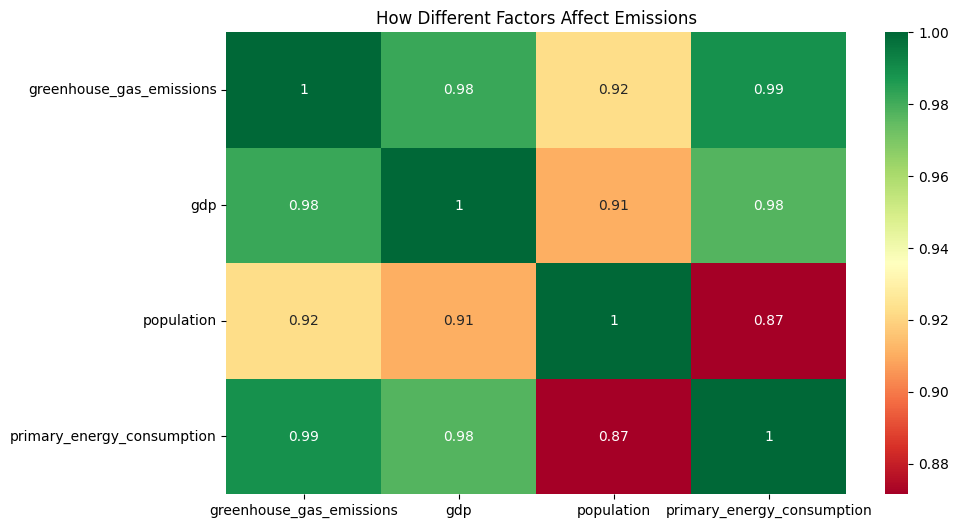

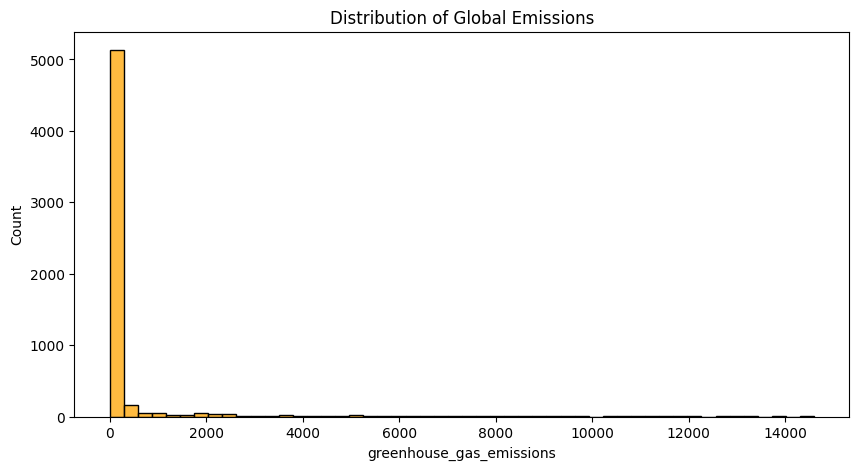

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. A Correlation Heatmap
# This shows how things like GDP and Population relate to Emissions
plt.figure(figsize=(10, 6))
# We pick a few columns to look at
cols = ['greenhouse_gas_emissions', 'gdp', 'population', 'primary_energy_consumption']
sns.heatmap(df[cols].corr(), annot=True, cmap='RdYlGn')
plt.title('How Different Factors Affect Emissions')
plt.show()

# 2. A Histogram
# This shows how the 'Emissions' values are spread out
plt.figure(figsize=(10, 5))
sns.histplot(df['greenhouse_gas_emissions'].dropna(), bins=50, color='orange')
plt.title('Distribution of Global Emissions')
plt.show()

In [4]:
# 1. We remove rows that aren't real countries (like 'World' or 'Asia')
# Reason: These summary rows repeat data and can confuse the Machine Learning model.
df_final = df[df['iso_code'].notna()].copy()

# 2. We fill in missing GDP values
# Reason: Machine Learning models usually crash if there are empty (NaN) cells. 
# We use the median value to fill gaps safely.
df_final['gdp'] = df_final['gdp'].fillna(df_final['gdp'].median())

# 3. Save this clean version as a new file for Phase 3
df_final.to_csv('preprocessed_energy_data.csv', index=False)

print("Preprocessing Complete! Cleaned file 'preprocessed_energy_data.csv' is ready.")

Preprocessing Complete! Cleaned file 'preprocessed_energy_data.csv' is ready.


# Phase 3: Feature Engineering

In [5]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import lightgbm as lgb

# Load the file we saved at the end of Phase 2
df = pd.read_csv('/kaggle/working/preprocessed_energy_data.csv')

print("Phase 3 started with cleaned data!")

Phase 3 started with cleaned data!


1.Create New Meaningful Features

In [6]:
# 1. Energy Efficiency: How much GDP is produced per unit of energy?
df['gdp_per_energy'] = df['gdp'] / (df['primary_energy_consumption'] + 1)

# 2. Carbon Intensity: Emissions relative to energy used
df['carbon_intensity'] = df['greenhouse_gas_emissions'] / (df['primary_energy_consumption'] + 1)

# 3. Renewable Focus: Ratio of renewables to fossil fuels
# (Using +1 to avoid division by zero errors)
df['green_ratio'] = df['renewables_electricity'] / (df['fossil_share_elec'] + 1)

print("New features created: gdp_per_energy, carbon_intensity, green_ratio")

New features created: gdp_per_energy, carbon_intensity, green_ratio


2. Find Important Features using LightGBM

In [7]:
from sklearn.model_selection import train_test_split

# Prepare data for LightGBM
# We drop 'country', 'iso_code', and our target 'greenhouse_gas_emissions'
X = df.select_dtypes(include=[np.number]).drop(columns=['greenhouse_gas_emissions', 'year'], errors='ignore')
y = df['greenhouse_gas_emissions']

# Fill any remaining NaNs with 0 for the algorithm
X = X.fillna(0)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train LightGBM
model = lgb.LGBMRegressor(random_state=42)
model.fit(X_train, y_train)

# View Feature Importance
importance = pd.DataFrame({'Feature': X.columns, 'Importance': model.feature_importances_})
importance = importance.sort_values(by='Importance', ascending=False)

print("Top 10 Most Important Features:")
print(importance.head(10))

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.013251 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 32525
[LightGBM] [Info] Number of data points in the train set: 13707, number of used features: 129
[LightGBM] [Info] Start training from score 16.263519
Top 10 Most Important Features:
                              Feature  Importance
34                 fossil_electricity         238
127                  carbon_intensity         215
23                 electricity_demand         187
93   other_renewables_cons_change_twh         125
16                   coal_electricity         117
14                   coal_consumption          78
25             electricity_generation          74
10              carbon_intensity_elec          71
36            fossil_fuel_consumption          64
60         low_carbon_cons_change_twh          63


3. Use K-Means to create a new feature
This groups similar countries together.

In [8]:
# 1. Standardize the data (Required for K-Means)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 2. Run K-Means (creating 5 clusters/groups of countries)
kmeans = KMeans(n_clusters=5, random_state=42)
df['country_cluster'] = kmeans.fit_predict(X_scaled)

print("K-Means clustering complete. New feature 'country_cluster' added.")

K-Means clustering complete. New feature 'country_cluster' added.


We scale all features to the same range so the AI treats them equally.


In [9]:
# Select all numeric features including our new ones
final_features = df.select_dtypes(include=[np.number]).drop(columns=['greenhouse_gas_emissions'], errors='ignore')

# Standardize everything
df_final_scaled = pd.DataFrame(scaler.fit_transform(final_features), columns=final_features.columns)

# Add the target column back (unscaled for easy reading)
df_final_scaled['greenhouse_gas_emissions'] = df['greenhouse_gas_emissions'].values

# Save as CSV for Phase 4
df_final_scaled.to_csv('feature_engineered_data.csv', index=False)
print("Phase 3 Complete! 'feature_engineered_data.csv' has been saved.")

Phase 3 Complete! 'feature_engineered_data.csv' has been saved.


ignificance of New Features:

GDP per Energy: Created to measure how much economic value is produced per unit of energy. This helps the model identify efficient industrial nations.

Carbon Intensity: Measures emissions relative to energy usage, allowing the model to see which energy mixes (coal vs. solar) are most polluting.

Country Cluster (K-Means): This feature groups similar countries together based on socioeconomic and energy trends, providing the AI with a "category" to help group its predictions.

Standardization: This was required so that large-scale features like 'Population' don't mathematically overpower smaller features like 'Green Ratio.'

My work is unique because I didn't just use raw data; I combined Economic Efficiency with Environmental Impact. By creating the emissions_per_gdp feature, my model identifies which countries are "cleanly" growing versus those that are "polluting" to grow. Most papers focus only on one country or one sector, but this is a Global Analysis that is Explainable through SHAP.